# OESD: Oriented Environmental Swiss Dwellings

# Dependencies

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
import csv
import os
import math

import shapely.wkt as wkt
import shapely.geometry as sg
from shapely.geometry import Polygon, MultiPolygon, box, LineString, Point
from shapely.ops import transform , unary_union, linemerge #cascaded_union
from shapely import affinity

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap, Normalize, BoundaryNorm, TwoSlopeNorm
from matplotlib.collections import PatchCollection
from matplotlib.cm import ScalarMappable, RdYlGn

from skimage import measure
import random
from PIL import Image

from ipywidgets import widgets
import time
import itertools

# Swiss Dwellings Data Load

To access the Swiss Dwellings dataset as the basis of O-ESD, it is assumed here that the dataset is dowloaded from the [Zenodo source](https://zenodo.org/records/7070952) and uploaded in the Google Drive storage.  

In [2]:
#mount google drive
drive.mount ('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [3]:
folder = "/content/gdrive/MyDrive/swiss_dwellings_v3.0.0"
os.chdir(folder)

In [4]:
df_simulation = pd.read_csv("simulations.csv")

In [5]:
df_simulation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367678 entries, 0 to 367677
Columns: 369 entries, site_id to layout_biggest_rectangle_width
dtypes: bool(10), float64(346), int64(10), object(3)
memory usage: 1010.6+ MB


In [6]:
#unique floor number
df_simulation.floor_number.nunique()

25

In [7]:
list(df_simulation.columns)

['site_id',
 'building_id',
 'plan_id',
 'floor_id',
 'unit_id',
 'area_id',
 'unit_usage',
 'apartment_id',
 'layout_compactness',
 'layout_is_navigable',
 'layout_mean_walllengths',
 'layout_area',
 'layout_net_area',
 'layout_room_count',
 'layout_std_walllengths',
 'layout_area_type',
 'layout_number_of_doors',
 'layout_number_of_windows',
 'layout_has_sink',
 'layout_has_shower',
 'layout_has_bathtub',
 'layout_has_stairs',
 'layout_has_entrance_door',
 'layout_has_toilet',
 'layout_perimeter',
 'layout_door_perimeter',
 'layout_window_perimeter',
 'layout_open_perimeter',
 'layout_railing_perimeter',
 'layout_connects_to_bathroom',
 'layout_connects_to_private_outdoor',
 'floor_number',
 'floor_has_elevator',
 'sun_201803210800_max',
 'sun_201803210800_mean',
 'sun_201803210800_median',
 'sun_201803210800_min',
 'sun_201803210800_p20',
 'sun_201803210800_p80',
 'sun_201803210800_stddev',
 'sun_201803211000_max',
 'sun_201803211000_mean',
 'sun_201803211000_median',
 'sun_20180321

In [8]:
df_geometry = pd.read_csv("geometries.csv")

In [17]:
df_geometry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3255905 entries, 0 to 3255904
Data columns (total 13 columns):
 #   Column          Dtype  
---  ------          -----  
 0   apartment_id    object 
 1   site_id         int64  
 2   building_id     int64  
 3   plan_id         int64  
 4   floor_id        int64  
 5   unit_id         float64
 6   area_id         float64
 7   unit_usage      object 
 8   entity_type     object 
 9   entity_subtype  object 
 10  geometry        object 
 11  elevation       float64
 12  height          float64
dtypes: float64(4), int64(4), object(5)
memory usage: 322.9+ MB


In [10]:
#unique site id number
df_geometry.site_id.nunique()

1466

In [11]:
df_geometry.building_id.nunique()

3184

In [12]:
df_geometry.area_id.nunique()

315036

In [13]:
df_geometry.elevation.nunique()

784

In [ ]:
#merging the geometry and simulation dataframes from SD is not even possible with 54GB RAM!
SD = df_geometry.merge(df_simulation, how= "left", on='area_id')

#renaming the column names with ending x
SD.rename(columns={'site_id_x': 'site_id', 'floor_id_x': 'floor_id', 'unit_id_x': 'unit_id', 'apartment_id_x':'apartment_id', 'building_id_x': 'building_id'}, inplace=True)

#dropping the columns with ending y cause they are repetetive
SD.drop(columns=['site_id_y', 'floor_id_y', 'unit_id_y', 'apartment_id_y', 'building_id_y'], inplace=True)
SD

In [14]:
pd.set_option('display.max_columns', None)
df_simulation

,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,apartment_id,layout_compactness,layout_is_navigable,layout_mean_walllengths,layout_area,layout_net_area,layout_room_count,layout_std_walllengths,layout_area_type,layout_number_of_doors,layout_number_of_windows,layout_has_sink,layout_has_shower,layout_has_bathtub,layout_has_stairs,layout_has_entrance_door,layout_has_toilet,layout_perimeter,layout_door_perimeter,layout_window_perimeter,layout_open_perimeter,layout_railing_perimeter,layout_connects_to_bathroom,layout_connects_to_private_outdoor,floor_number,floor_has_elevator,sun_201803210800_max,sun_201803210800_mean,sun_201803210800_median,sun_201803210800_min,sun_201803210800_p20,sun_201803210800_p80,sun_201803210800_stddev,sun_201803211000_max,sun_201803211000_mean,sun_201803211000_median,sun_201803211000_min,sun_201803211000_p20,sun_201803211000_p80,sun_201803211000_stddev,sun_201803211200_max,sun_201803211200_mean,sun_201803211200_median,sun_201803211200_min,sun_201803211200_p20,sun_201803211200_p80,sun_201803211200_stddev,sun_201803211400_max,sun_201803211400_mean,sun_201803211400_median,sun_201803211400_min,sun_201803211400_p20,sun_201803211400_p80,sun_201803211400_stddev,sun_201803211600_max,sun_201803211600_mean,sun_201803211600_median,sun_201803211600_min,sun_201803211600_p20,sun_201803211600_p80,sun_201803211600_stddev,sun_201803211800_max,sun_201803211800_mean,sun_201803211800_median,sun_201803211800_min,sun_201803211800_p20,sun_201803211800_p80,sun_201803211800_stddev,sun_201806210600_max,sun_201806210600_mean,sun_201806210600_median,sun_201806210600_min,sun_201806210600_p20,sun_201806210600_p80,sun_201806210600_stddev,sun_201806210800_max,sun_201806210800_mean,sun_201806210800_median,sun_201806210800_min,sun_201806210800_p20,sun_201806210800_p80,sun_201806210800_stddev,sun_201806211000_max,sun_201806211000_mean,sun_201806211000_median,sun_201806211000_min,sun_201806211000_p20,sun_201806211000_p80,sun_201806211000_stddev,sun_201806211200_max,sun_201806211200_mean,sun_201806211200_median,sun_201806211200_min,sun_201806211200_p20,sun_201806211200_p80,sun_201806211200_stddev,sun_201806211400_max,sun_201806211400_mean,sun_201806211400_median,sun_201806211400_min,sun_201806211400_p20,sun_201806211400_p80,sun_201806211400_stddev,sun_201806211600_max,sun_201806211600_mean,sun_201806211600_median,sun_201806211600_min,sun_201806211600_p20,sun_201806211600_p80,sun_201806211600_stddev,sun_201806211800_max,sun_201806211800_mean,sun_201806211800_median,sun_201806211800_min,sun_201806211800_p20,sun_201806211800_p80,sun_201806211800_stddev,sun_201806212000_max,sun_201806212000_mean,sun_201806212000_median,sun_201806212000_min,sun_201806212000_p20,sun_201806212000_p80,sun_201806212000_stddev,sun_201812211000_max,sun_201812211000_mean,sun_201812211000_median,sun_201812211000_min,sun_201812211000_p20,sun_201812211000_p80,sun_201812211000_stddev,sun_201812211200_max,sun_201812211200_mean,sun_201812211200_median,sun_201812211200_min,sun_201812211200_p20,sun_201812211200_p80,sun_201812211200_stddev,sun_201812211400_max,sun_201812211400_mean,sun_201812211400_median,sun_201812211400_min,sun_201812211400_p20,sun_201812211400_p80,sun_201812211400_stddev,sun_201812211600_max,sun_201812211600_mean,sun_201812211600_median,sun_201812211600_min,sun_201812211600_p20,sun_201812211600_p80,sun_201812211600_stddev,view_buildings_max,view_buildings_mean,view_buildings_median,view_buildings_min,view_buildings_p20,view_buildings_p80,view_buildings_stddev,view_greenery_max,view_greenery_mean,view_greenery_median,view_greenery_min,view_greenery_p20,view_greenery_p80,view_greenery_stddev,view_ground_max,view_ground_mean,view_ground_median,view_ground_min,view_ground_p20,view_ground_p80,view_ground_stddev,view_isovist_max,view_isovist_mean,view_isovist_median,view_isovist_min,view_isovist_p20,view_isovist_p80,view_isovist_stddev,view_mountains_class_2_max,view_mountains_class_2_mean,view_mountains_class_2_median,view_mountains_class_2_min,view

In [15]:
#unique values in layout_area_type
df_simulation.layout_area_type.unique()

array(['Room', 'Kitchen', 'Bathroom', 'Corridor', 'Balcony',
       'StorageRoom', 'Loggia', 'LivingKitchen', 'SunRoom'], dtype=object)

In [16]:
#how many Sunrooms do we have in layout_area_type
df_simulation.layout_area_type.value_counts()

,count
layout_area_type,
Room,139557
Bathroom,68420
Corridor,53432
Kitchen,44075
Balcony,43078
StorageRoom,14344
Loggia,4400
SunRoom,331
LivingKitchen,41


# Data Refinement

In [18]:
#checking whether there are duplicates in the dataframes
df_simulation.drop_duplicates(inplace=True)
df_simulation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367678 entries, 0 to 367677
Columns: 369 entries, site_id to layout_biggest_rectangle_width
dtypes: bool(10), float64(346), int64(10), object(3)
memory usage: 1010.6+ MB


simulation dataframe has no duplicate values

In [19]:
#checking whether there are duplicates in the dataframes
df_geometry.drop_duplicates(inplace=True, ignore_index=True)
df_geometry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3255786 entries, 0 to 3255785
Data columns (total 13 columns):
 #   Column          Dtype  
---  ------          -----  
 0   apartment_id    object 
 1   site_id         int64  
 2   building_id     int64  
 3   plan_id         int64  
 4   floor_id        int64  
 5   unit_id         float64
 6   area_id         float64
 7   unit_usage      object 
 8   entity_type     object 
 9   entity_subtype  object 
 10  geometry        object 
 11  elevation       float64
 12  height          float64
dtypes: float64(4), int64(4), object(5)
memory usage: 322.9+ MB


So, as the very first step, the number of rows in the df_geometry dropped from 3255905 to 3255786 as a results of dropping duplicate rows

In [20]:
df_geometry.unit_usage.unique()

array(['RESIDENTIAL', 'PUBLIC', 'COMMERCIAL', 'JANITOR', 'PLACEHOLDER'],
      dtype=object)

In [21]:
df_geometry.entity_type.unique()

array(['area', 'feature', 'separator', 'opening'], dtype=object)

In [22]:
#lets see what exactly are the areas
df_geometry_area = df_geometry[df_geometry["entity_type"] == "area"]
df_geometry_area.entity_subtype.unique()

array(['BATHROOM', 'LIVING_ROOM', 'ROOM', 'KITCHEN', 'BALCONY',
       'CORRIDOR', 'DINING', 'SHAFT', 'STAIRCASE', 'STOREROOM',
       'LIVING_DINING', 'BASEMENT_COMPARTMENT', 'VOID', 'ELEVATOR',
       'NOT_DEFINED', 'OFFICE', 'BEDROOM', 'OUTDOOR_VOID', 'LOGGIA',
       'KITCHEN_DINING', 'PRAM', 'LIGHTWELL', 'TERRACE',
       'PRAM_AND_BIKE_STORAGE_ROOM', 'CORRIDORS_AND_HALLS',
       'BIKE_STORAGE', 'COUNTER_ROOM', 'BASEMENT', 'TECHNICAL_AREA',
       'HEATING', 'LOBBY', 'WINTERGARTEN', 'WASH_AND_DRY_ROOM',
       'CLOAKROOM', 'SALESROOM', 'GARAGE', 'OIL_TANK', 'FOYER',
       'HOUSE_TECHNICS_FACILITIES', 'OFFICE_SPACE', 'OFFICE_TECH_ROOM',
       'WAREHOUSE', 'CARPARK', 'SANITARY_ROOMS', 'OPEN_PLAN_OFFICE',
       'MEETING_ROOM', 'BREAK_ROOM', 'ARCHIVE', 'ELECTRICAL_SUPPLY',
       'MEDICAL_ROOM', 'WAITING_ROOM', 'COMMON_KITCHEN',
       'VEHICLE_TRAFFIC_AREA', 'ELEVATOR_FACILITIES', 'AIR', 'PATIO',
       'FACTORY_ROOM', 'RECEPTION_ROOM', 'COMMUNITY_ROOM', 'WORKSHOP',
       'GARDE

This much of variety in the area types show the diversity of the dataset in terms of "Dwelling" types. The root difference might be found from unit usage variety.

In [23]:
#lets see what exactly are the features
df_geometry_features = df_geometry[df_geometry["entity_type"] == "feature"]
df_geometry_features.entity_subtype.unique()

array(['BATHTUB', 'TOILET', 'SINK', 'KITCHEN', 'STAIRS', 'SHOWER',
       'ELEVATOR', 'WASHING_MACHINE', 'RAMP', 'BUILT_IN_FURNITURE'],
      dtype=object)

In [24]:
#lets see what exactly are the separators
df_geometry_separator = df_geometry[df_geometry["entity_type"] == "separator"]
df_geometry_separator.entity_subtype.unique()

array(['WALL', 'RAILING', 'COLUMN'], dtype=object)

In [25]:
#and, lets see what exactly are the openings
df_geometry_opening = df_geometry[df_geometry["entity_type"] == "opening"]
df_geometry_opening.entity_subtype.unique()

array(['DOOR', 'WINDOW', 'ENTRANCE_DOOR'], dtype=object)

In [26]:
df_geometry.entity_subtype.unique()

array(['BATHROOM', 'LIVING_ROOM', 'ROOM', 'KITCHEN', 'BALCONY',
       'CORRIDOR', 'BATHTUB', 'TOILET', 'SINK', 'WALL', 'RAILING', 'DOOR',
       'WINDOW', 'ENTRANCE_DOOR', 'DINING', 'SHAFT', 'STAIRCASE',
       'STAIRS', 'STOREROOM', 'COLUMN', 'SHOWER', 'LIVING_DINING',
       'BASEMENT_COMPARTMENT', 'VOID', 'ELEVATOR', 'NOT_DEFINED',
       'OFFICE', 'BEDROOM', 'OUTDOOR_VOID', 'LOGGIA', 'KITCHEN_DINING',
       'PRAM', 'LIGHTWELL', 'WASHING_MACHINE', 'TERRACE',
       'PRAM_AND_BIKE_STORAGE_ROOM', 'CORRIDORS_AND_HALLS',
       'BIKE_STORAGE', 'COUNTER_ROOM', 'BASEMENT', 'TECHNICAL_AREA',
       'HEATING', 'LOBBY', 'WINTERGARTEN', 'RAMP', 'WASH_AND_DRY_ROOM',
       'BUILT_IN_FURNITURE', 'CLOAKROOM', 'SALESROOM', 'GARAGE',
       'OIL_TANK', 'FOYER', 'HOUSE_TECHNICS_FACILITIES', 'OFFICE_SPACE',
       'OFFICE_TECH_ROOM', 'WAREHOUSE', 'CARPARK', 'SANITARY_ROOMS',
       'OPEN_PLAN_OFFICE', 'MEETING_ROOM', 'BREAK_ROOM', 'ARCHIVE',
       'ELECTRICAL_SUPPLY', 'MEDICAL_ROOM', 'WAITING_ROO

In [27]:
#curious to see what exactly is there for COMMERCIAL unit_usage
df_geometry_commercial = df_geometry[df_geometry["unit_usage"] == "COMMERCIAL"]
df_geometry_commercial.entity_subtype.unique()

array(['CLOAKROOM', 'BATHROOM', 'SALESROOM', 'TOILET', 'SINK', 'WALL',
       'COLUMN', 'ENTRANCE_DOOR', 'WINDOW', 'DOOR', 'LOBBY',
       'OFFICE_SPACE', 'BUILT_IN_FURNITURE', 'OFFICE_TECH_ROOM', 'VOID',
       'TERRACE', 'CORRIDORS_AND_HALLS', 'STAIRS', 'RAILING', 'OFFICE',
       'SHAFT', 'STOREROOM', 'OPEN_PLAN_OFFICE', 'MEETING_ROOM',
       'SANITARY_ROOMS', 'BREAK_ROOM', 'ARCHIVE', 'BASEMENT', 'BALCONY',
       'COMMON_KITCHEN', 'FACTORY_ROOM', 'RECEPTION_ROOM', 'WORKSHOP',
       'COMMUNITY_ROOM', 'PATIO', 'KITCHEN', 'SHOWER', 'CANTEEN',
       'WAREHOUSE', 'COLD_STORAGE', 'TRANSPORT_SHAFT', 'WASHING_MACHINE',
       'RADATION_THERAPY', 'PHYSIO_AND_REHABILITATION', 'MEDICAL_ROOM',
       'STAIRCASE', 'SHOWROOM', 'BASEMENT_COMPARTMENT', 'TEACHING_ROOM',
       'BATHTUB', 'SPORTS_ROOMS', 'WAITING_ROOM', 'ELEVATOR', 'LOGGIA',
       'ARCADE', 'LOGISTICS'], dtype=object)

Although the dataset is called Swiss "Dwellings", there are some completely different space types, such as office-related areas.

In [28]:
#also, curious to see what exactly is there for JANITOR unit usage
df_geometry_janitor = df_geometry[df_geometry["unit_usage"] == "JANITOR"]
df_geometry_janitor.entity_subtype.unique()

array(['OFFICE', 'BATHROOM', 'BUILT_IN_FURNITURE', 'TOILET', 'SINK',
       'WALL', 'WINDOW', 'ENTRANCE_DOOR', 'DOOR'], dtype=object)

In [29]:
#and finally, what is under the PLACEHOLDER unit usage?
df_geometry_placeholder = df_geometry[df_geometry["unit_usage"] == "PLACEHOLDER"]
df_geometry_placeholder.entity_subtype.unique()

array(['SHAFT', 'BASEMENT_COMPARTMENT', 'CORRIDOR', 'HEATING',
       'LIGHTWELL', 'WALL', 'WINDOW', 'DOOR', 'ENTRANCE_DOOR',
       'BIKE_STORAGE', 'WASH_AND_DRY_ROOM', 'WASHING_MACHINE'],
      dtype=object)

Apparently, all the incompatible entity_subtypes to my task are place under COMMERCIAL, JANITOR, and PLACEHOLDER. Therefore, we will further work only with RESIDENTIAL and PUBLIC. Let's check what the entity_subtypes are there under these two.

In [30]:
#what is under residential
df_geometry_residential = df_geometry[df_geometry["unit_usage"] == "RESIDENTIAL"]
df_geometry_residential.entity_subtype.unique()

array(['BATHROOM', 'LIVING_ROOM', 'ROOM', 'KITCHEN', 'BALCONY',
       'CORRIDOR', 'BATHTUB', 'TOILET', 'SINK', 'WALL', 'RAILING', 'DOOR',
       'WINDOW', 'ENTRANCE_DOOR', 'DINING', 'SHAFT', 'STOREROOM',
       'STAIRS', 'COLUMN', 'SHOWER', 'LIVING_DINING', 'STAIRCASE',
       'BEDROOM', 'OUTDOOR_VOID', 'LOGGIA', 'VOID', 'KITCHEN_DINING',
       'WASHING_MACHINE', 'TERRACE', 'WINTERGARTEN', 'BUILT_IN_FURNITURE',
       'LIGHTWELL', 'ELEVATOR', 'PATIO', 'GARDEN', 'TECHNICAL_AREA',
       'STUDIO'], dtype=object)

In [31]:
#and what is under PUBLIC
df_geometry_public = df_geometry[df_geometry["unit_usage"] == "PUBLIC"]
df_geometry_public.entity_subtype.unique()

array(['SHAFT', 'STAIRCASE', 'STAIRS', 'WALL', 'WINDOW', 'ENTRANCE_DOOR',
       'DOOR', 'CORRIDOR', 'BASEMENT_COMPARTMENT', 'STOREROOM',
       'BATHROOM', 'TOILET', 'SINK', 'VOID', 'COLUMN', 'RAILING',
       'ELEVATOR', 'NOT_DEFINED', 'OFFICE', 'BEDROOM', 'BALCONY',
       'LOGGIA', 'KITCHEN', 'ROOM', 'LIVING_DINING', 'SHOWER', 'PRAM',
       'KITCHEN_DINING', 'LIGHTWELL', 'PRAM_AND_BIKE_STORAGE_ROOM',
       'CORRIDORS_AND_HALLS', 'BIKE_STORAGE', 'COUNTER_ROOM', 'BASEMENT',
       'TECHNICAL_AREA', 'HEATING', 'LOBBY', 'LIVING_ROOM', 'RAMP',
       'OUTDOOR_VOID', 'WINTERGARTEN', 'BATHTUB', 'WASH_AND_DRY_ROOM',
       'WASHING_MACHINE', 'BUILT_IN_FURNITURE', 'GARAGE', 'OIL_TANK',
       'FOYER', 'HOUSE_TECHNICS_FACILITIES', 'WAREHOUSE', 'CARPARK',
       'SANITARY_ROOMS', 'ELECTRICAL_SUPPLY', 'ARCHIVE', 'MEDICAL_ROOM',
       'CLOAKROOM', 'BREAK_ROOM', 'WAITING_ROOM', 'VEHICLE_TRAFFIC_AREA',
       'ELEVATOR_FACILITIES', 'MEETING_ROOM', 'OFFICE_TECH_ROOM',
       'OFFICE_SPACE', 'TE

Although some entity sub_types under the unit usage of PUBLIC look useful, we cannot further work with them becauase of lack of corresponding data in the simulation dataframe.

In [32]:
#the main reason of length difference between simulation and geometry files
df_simulation.unit_usage.unique()

array(['RESIDENTIAL'], dtype=object)

However, there are no simulation results for any unit usage other than RESIDENTIAL. Therefore, it makes sense to only keep RESIDENTIAL unit_usage in the geometry dataframe as well.

In [33]:
#Filter out non residential data from geometry files
df_geometry = df_geometry[df_geometry["unit_usage"] == "RESIDENTIAL"]
df_geometry.unit_usage.unique()

array(['RESIDENTIAL'], dtype=object)

In [34]:
#dropping the unit_usage column since it only has one value now
#dropping unit_usage column from df_geometry
df_geometry.drop(columns=['unit_usage'], inplace=True)

In [35]:
df_geometry.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2650729 entries, 0 to 3252521
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   apartment_id    object 
 1   site_id         int64  
 2   building_id     int64  
 3   plan_id         int64  
 4   floor_id        int64  
 5   unit_id         float64
 6   area_id         float64
 7   entity_type     object 
 8   entity_subtype  object 
 9   geometry        object 
 10  elevation       float64
 11  height          float64
dtypes: float64(4), int64(4), object(4)
memory usage: 262.9+ MB


In the second step, after removing any other unit usage type than residential, the number of row in the df_geometry dropped to 2650729

In [36]:
#there is also no need to keep the features from the entity_types in the geometry dataframe
df_geometry = df_geometry[df_geometry["entity_type"] != "feature"]
df_geometry.entity_subtype.unique()

array(['BATHROOM', 'LIVING_ROOM', 'ROOM', 'KITCHEN', 'BALCONY',
       'CORRIDOR', 'WALL', 'RAILING', 'DOOR', 'WINDOW', 'ENTRANCE_DOOR',
       'DINING', 'SHAFT', 'STOREROOM', 'COLUMN', 'LIVING_DINING',
       'STAIRCASE', 'BEDROOM', 'OUTDOOR_VOID', 'LOGGIA', 'VOID',
       'KITCHEN_DINING', 'TERRACE', 'WINTERGARTEN', 'LIGHTWELL',
       'ELEVATOR', 'PATIO', 'GARDEN', 'TECHNICAL_AREA', 'STUDIO'],
      dtype=object)

In [37]:
df_geometry.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2385165 entries, 0 to 3252521
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   apartment_id    object 
 1   site_id         int64  
 2   building_id     int64  
 3   plan_id         int64  
 4   floor_id        int64  
 5   unit_id         float64
 6   area_id         float64
 7   entity_type     object 
 8   entity_subtype  object 
 9   geometry        object 
 10  elevation       float64
 11  height          float64
dtypes: float64(4), int64(4), object(4)
memory usage: 236.6+ MB


In the third step, after removing the feature entity_types, the number of rows in the geometry dataframe dropped to 2385165

In [38]:
#also, based on plots, it is not necessary to keep railings from entity_subtypes
df_geometry = df_geometry[df_geometry["entity_subtype"] != "RAILING"]
df_geometry.entity_subtype.unique()

array(['BATHROOM', 'LIVING_ROOM', 'ROOM', 'KITCHEN', 'BALCONY',
       'CORRIDOR', 'WALL', 'DOOR', 'WINDOW', 'ENTRANCE_DOOR', 'DINING',
       'SHAFT', 'STOREROOM', 'COLUMN', 'LIVING_DINING', 'STAIRCASE',
       'BEDROOM', 'OUTDOOR_VOID', 'LOGGIA', 'VOID', 'KITCHEN_DINING',
       'TERRACE', 'WINTERGARTEN', 'LIGHTWELL', 'ELEVATOR', 'PATIO',
       'GARDEN', 'TECHNICAL_AREA', 'STUDIO'], dtype=object)

In [39]:
df_geometry.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2239274 entries, 0 to 3252521
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   apartment_id    object 
 1   site_id         int64  
 2   building_id     int64  
 3   plan_id         int64  
 4   floor_id        int64  
 5   unit_id         float64
 6   area_id         float64
 7   entity_type     object 
 8   entity_subtype  object 
 9   geometry        object 
 10  elevation       float64
 11  height          float64
dtypes: float64(4), int64(4), object(4)
memory usage: 222.1+ MB


In the fourth step, after removing the railings entity-subtype, the number of rows in geometry dataframe dropped to 2239274

In [40]:
#reseting the index after each step to keep things organized
df_geometry.reset_index(drop=True, inplace=True)

In [41]:
df_geometry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239274 entries, 0 to 2239273
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   apartment_id    object 
 1   site_id         int64  
 2   building_id     int64  
 3   plan_id         int64  
 4   floor_id        int64  
 5   unit_id         float64
 6   area_id         float64
 7   entity_type     object 
 8   entity_subtype  object 
 9   geometry        object 
 10  elevation       float64
 11  height          float64
dtypes: float64(4), int64(4), object(4)
memory usage: 205.0+ MB


In [42]:
#curious about remaining entity sub_types in the geometry dataframe
df_geometry.entity_subtype.unique()

array(['BATHROOM', 'LIVING_ROOM', 'ROOM', 'KITCHEN', 'BALCONY',
       'CORRIDOR', 'WALL', 'DOOR', 'WINDOW', 'ENTRANCE_DOOR', 'DINING',
       'SHAFT', 'STOREROOM', 'COLUMN', 'LIVING_DINING', 'STAIRCASE',
       'BEDROOM', 'OUTDOOR_VOID', 'LOGGIA', 'VOID', 'KITCHEN_DINING',
       'TERRACE', 'WINTERGARTEN', 'LIGHTWELL', 'ELEVATOR', 'PATIO',
       'GARDEN', 'TECHNICAL_AREA', 'STUDIO'], dtype=object)

Here the intended attribute of the simulation dataframe are selected. Check the paper for additional information regarding the selection reasoning.

In [43]:
df_simulation = df_simulation[['site_id','building_id','floor_id','unit_id','area_id','apartment_id', 'floor_number', #IDs
                               'layout_compactness', 'layout_area', 'layout_net_area', 'layout_biggest_rectangle_length','layout_biggest_rectangle_width',
                               'layout_number_of_doors', 'layout_number_of_windows', 'layout_window_perimeter', #shape-related
                               'sun_201812211000_p80',  'sun_201812211600_p80', #daylight (December- overcast sky)
                               'view_buildings_p80', 'view_sky_p80','view_greenery_p80', 'view_ground_p80', 'view_water_p80', 'view_site_p80',
                               'view_mountains_class_2_p80', 'view_mountains_class_3_p80', 'view_mountains_class_4_p80', 'view_mountains_class_5_p80', 'view_mountains_class_6_p80',
                               'view_railway_tracks_p80', 'view_highways_p80', 'view_primary_streets_p80', 'view_secondary_streets_p80', 'view_tertiary_streets_p80', 'view_pedestrians_p80', #view
                               'noise_traffic_night', 'noise_train_night']] #noise for nighttime

In [44]:
df_simulation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367678 entries, 0 to 367677
Data columns (total 36 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   site_id                          367678 non-null  int64  
 1   building_id                      367678 non-null  int64  
 2   floor_id                         367678 non-null  int64  
 3   unit_id                          367678 non-null  int64  
 4   area_id                          367678 non-null  int64  
 5   apartment_id                     367678 non-null  object 
 6   floor_number                     367678 non-null  int64  
 7   layout_compactness               367678 non-null  float64
 8   layout_area                      367678 non-null  float64
 9   layout_net_area                  367678 non-null  float64
 10  layout_biggest_rectangle_length  367620 non-null  float64
 11  layout_biggest_rectangle_width   367620 non-null  float64
 12  la

# Attribute transformation

### Zoning

Grouping spaces into zones, based on the environmental demands:

In [45]:
#creating a new column in geometry dataframe and call it zoning
df_geometry['zoning'] = df_geometry['entity_subtype']
#then replace all of the entity_subtypes with correspoding zones based on environmental demands
df_geometry['zoning'] = df_geometry['zoning'].replace(['ROOM', 'BEDROOM', 'STUDIO'],
                                                      'zone01') #morning daylight and noise avoidance
df_geometry['zoning'] = df_geometry['zoning'].replace(['LIVING_ROOM', 'KITCHEN', 'DINING', 'LIVING_DINING', 'KITCHEN_DINING'],
                                                      'zone02') #evening daylight and view
df_geometry['zoning'] = df_geometry['zoning'].replace(['CORRIDOR', 'STOREROOM', 'STAIRCASE', 'BATHROOM'],
                                                      'zone03') #no demand #passive interior zone
df_geometry['zoning'] = df_geometry['zoning'].replace(['BALCONY', 'LOGGIA', 'TERRACE', 'WINTERGARTEN', 'GARDEN', 'OUTDOOR_VOID'],
                                                      'zone04') #noise and thermal barrier, view provision #serving zone
df_geometry['zoning'] = df_geometry['zoning'].replace(['SHAFT', 'VOID', 'LIGHTWELL', 'PATIO', 'ELEVATOR', 'TECHNICAL_AREA'],
                                                      'remaining')
df_geometry

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,entity_type,entity_subtype,geometry,elevation,height,zoning
0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03
1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,zone02
2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,area,ROOM,POLYGON ((6.7557107205191187 2.413369594812586...,0.0,2.6,zone01
3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,area,KITCHEN,POLYGON ((3.5821200013910017 5.140461688341117...,0.0,2.6,zone02
4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,area,ROOM,POLYGON ((3.0141380455489282 4.182056855151666...,0.0,2.6,zone01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239269,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,DOOR,POLYGON ((7.0234066847081849 0.077783062237456...,14.5,2.0,DOOR
2239270,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((-3.8996073759915930 -6.5850969690244...,15.0,1.9,WINDOW
2239271,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((-0.1737787481773516 -6.5912319562452...,15.0,1.9,WINDOW
2239272,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((3.1673230409108726 -6.59123195624521...,15.0,1.9,WINDOW


In [46]:
df_geometry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239274 entries, 0 to 2239273
Data columns (total 13 columns):
 #   Column          Dtype  
---  ------          -----  
 0   apartment_id    object 
 1   site_id         int64  
 2   building_id     int64  
 3   plan_id         int64  
 4   floor_id        int64  
 5   unit_id         float64
 6   area_id         float64
 7   entity_type     object 
 8   entity_subtype  object 
 9   geometry        object 
 10  elevation       float64
 11  height          float64
 12  zoning          object 
dtypes: float64(4), int64(4), object(5)
memory usage: 222.1+ MB


In [47]:
#unique entity subtypes under entity type area
df_geometry.loc[df_geometry['entity_type'] == "area"].entity_subtype.unique()

array(['BATHROOM', 'LIVING_ROOM', 'ROOM', 'KITCHEN', 'BALCONY',
       'CORRIDOR', 'DINING', 'SHAFT', 'STOREROOM', 'LIVING_DINING',
       'STAIRCASE', 'BEDROOM', 'OUTDOOR_VOID', 'LOGGIA', 'VOID',
       'KITCHEN_DINING', 'TERRACE', 'WINTERGARTEN', 'LIGHTWELL',
       'ELEVATOR', 'PATIO', 'GARDEN', 'TECHNICAL_AREA', 'STUDIO'],
      dtype=object)

In [48]:
#first locate the row with entity type of area
area = df_geometry.loc[df_geometry['entity_type'] == "area"]
#then see the unique zone types to make sure the whole areas are covered
area.zoning.unique()

array(['zone03', 'zone02', 'zone01', 'zone04', 'remaining'], dtype=object)

In [49]:
#unique values under zoning
df_geometry.zoning.unique()

array(['zone03', 'zone02', 'zone01', 'zone04', 'WALL', 'DOOR', 'WINDOW',
       'ENTRANCE_DOOR', 'remaining', 'COLUMN'], dtype=object)

In [50]:
#number of unique values in geometry
print(df_geometry.nunique())

apartment_id        44894
site_id              1460
building_id          3173
plan_id              8729
floor_id            13693
unit_id             46937
area_id            259245
entity_type             3
entity_subtype         29
geometry          1243479
elevation             522
height                141
zoning                 10
dtype: int64


## Daylight

After selecting the intended features, two columns are added to present proxy Daylight Factor (DF) inspired by the BREEAM NL guidelines. Since DF is calculated under the overcast sky, the illuminance results of December 21st were only kept in the initial simulation dataframe, because of a better representation of the overcast sky comparing to June or March. Yet, to make it more dynamic and precise, two types of DFs are newly defined: one for the morning (10:00) and one for the late afternoon (16:00). They are accordingly called Morning Illuminance Factor (MIF), and Afternoon Illuminance Factor (AIF).

In [51]:
#add a column with the name DF with sun values for morning and afternoon of march
df_simulation['MIF'] = df_simulation.sun_201812211000_p80
df_simulation['AIF'] = df_simulation.sun_201812211600_p80
#dividing each values of the column DF by its maximum value
df_simulation['MIF'] = df_simulation['MIF']/df_simulation['MIF'].max()*100
df_simulation['AIF'] = df_simulation['AIF']/df_simulation['AIF'].max()*100
df_simulation

/tmp/ipykernel_17427/1650791886.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_simulation['MIF'] = df_simulation.sun_201812211000_p80
/tmp/ipykernel_17427/1650791886.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_simulation['AIF'] = df_simulation.sun_201812211600_p80
/tmp/ipykernel_17427/1650791886.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

,site_id,building_id,floor_id,unit_id,area_id,apartment_id,floor_number,layout_compactness,layout_area,layout_net_area,layout_biggest_rectangle_length,layout_biggest_rectangle_width,layout_number_of_doors,layout_number_of_windows,layout_window_perimeter,sun_201812211000_p80,sun_201812211600_p80,view_buildings_p80,view_sky_p80,view_greenery_p80,view_ground_p80,view_water_p80,view_site_p80,view_mountains_class_2_p80,view_mountains_class_3_p80,view_mountains_class_4_p80,view_mountains_class_5_p80,view_mountains_class_6_p80,view_railway_tracks_p80,view_highways_p80,view_primary_streets_p80,view_secondary_streets_p80,view_tertiary_streets_p80,view_pedestrians_p80,noise_traffic_night,noise_train_night,MIF,AIF
0,210,399,1588,7300,619322,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.751449,17.214329,17.214329,4.453946,3.539037,2,1,1.604040,0.074216,0.040198,0.023491,0.001097,0.004703,0.025015,0.000000,0.981397,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000302,0.000000,29.962701,0.0,0.545955,0.565784
1,210,399,1588,7300,619310,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.768121,12.813539,12.813539,4.156488,3.082780,3,1,1.748906,0.240147,0.117009,0.046333,0.003848,0.000990,0.022701,0.000000,0.974323,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.002131,0.000000,22.959826,0.0,1.766598,1.646898
2,210,399,1588,7300,619311,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.701784,3.515454,3.515454,2.357677,1.429785,1,1,0.572940,0.065763,0.030427,0.024132,0.000030,0.000000,0.010558,0.000000,0.987207,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,17.531347,0.0,0.483775,0.428257
3,210,399,1588,7300,619303,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.777285,14.088640,14.088640,4.156488,3.389554,1,1,1.859685,0.387583,0.189876,0.020634,0.010146,0.004209,0.023664,0.000000,0.977193,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.005970,0.000000,28.956064,0.0,2.851179,2.672495
4,210,399,1588,7300,619315,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.785398,2.840086,2.840086,1.685255,1.685255,4,0,0.000000,0.024147,0.010036,0.011495,0.000195,0.000369,0.003890,0.000000,0.994093,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000732,0.000000,0.000000,0.0,0.177629,0.141254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367673,855,1810,8035,28198,1071889,b0027ca76f79c5363ef036f4332fe78c,5,0.581065,3.114156,0.000000,2.588957,1.116497,1,2,1.988564,5.863509,2.288880,0.005373,0.287453,0.027097,0.094609,0.000027,0.733859,0.0,0.0,0.000080,0.000084,0.001249,0.0,0.0,0.0,0.000000,0.001309,0.000480,33.503868,0.0,43.133765,32.215870
367674,855,1810,8035,28198,316663,b0027ca76f79c5363ef036f4332fe78c,5,0.735947,12.504983,12.504983,4.096324,2.886985,1,2,2.759874,2.425443,0.508911,0.020928,0.039975,0.042185,0.018486,0.000000,0.980009,0.0,0.0,0.000000,0.000093,0.001835,0.0,0.0,0.0,0.000105,0.000571,0.000051,40.194881,0.0,17.842298,7.162899
367675,855,1810,8035,28198,316661,b0027ca76f79c5363ef036f4332fe78c,5,0.683924,3.105185,3.105185,2.186603,1.297532,4,0,0.000000,0.704453,0.186465,0.005833,0.010731,0.008487,0.008573,0.000000,0.980407,0.0,0.0,0.000243,0.000318,0.001396,0.0,0.0,0.0,0.000018,0.000000,0.000039,35.345835,0.0,5.182172,2.624483
367676,855,1810,8035,28198,316666,b0027ca76f79c5363ef036f4332fe78c,5,0.552144,6.867870,6.867870,3.352649,1.577630,1,1,1.162000,0.522025,0.211691,0.000680,0.028382,0.002563,0.007849,0.000000,0.994382,0.0,0.0,0.000000,0.000000,0.000185,0.0,0.0,0.0,0.000000,0.000092,0.000029,29.224081,0.0,3.840175,2.979536


In [52]:
df_simulation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367678 entries, 0 to 367677
Data columns (total 38 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   site_id                          367678 non-null  int64  
 1   building_id                      367678 non-null  int64  
 2   floor_id                         367678 non-null  int64  
 3   unit_id                          367678 non-null  int64  
 4   area_id                          367678 non-null  int64  
 5   apartment_id                     367678 non-null  object 
 6   floor_number                     367678 non-null  int64  
 7   layout_compactness               367678 non-null  float64
 8   layout_area                      367678 non-null  float64
 9   layout_net_area                  367678 non-null  float64
 10  layout_biggest_rectangle_length  367620 non-null  float64
 11  layout_biggest_rectangle_width   367620 non-null  float64
 12  la

In [53]:
#droping the daylight columns
df_simulation.drop(columns=['sun_201812211000_p80', 'sun_201812211600_p80'], inplace=True)
df_simulation

/tmp/ipykernel_17427/4169119870.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_simulation.drop(columns=['sun_201812211000_p80', 'sun_201812211600_p80'], inplace=True)


,site_id,building_id,floor_id,unit_id,area_id,apartment_id,floor_number,layout_compactness,layout_area,layout_net_area,layout_biggest_rectangle_length,layout_biggest_rectangle_width,layout_number_of_doors,layout_number_of_windows,layout_window_perimeter,view_buildings_p80,view_sky_p80,view_greenery_p80,view_ground_p80,view_water_p80,view_site_p80,view_mountains_class_2_p80,view_mountains_class_3_p80,view_mountains_class_4_p80,view_mountains_class_5_p80,view_mountains_class_6_p80,view_railway_tracks_p80,view_highways_p80,view_primary_streets_p80,view_secondary_streets_p80,view_tertiary_streets_p80,view_pedestrians_p80,noise_traffic_night,noise_train_night,MIF,AIF
0,210,399,1588,7300,619322,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.751449,17.214329,17.214329,4.453946,3.539037,2,1,1.604040,0.023491,0.001097,0.004703,0.025015,0.000000,0.981397,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000302,0.000000,29.962701,0.0,0.545955,0.565784
1,210,399,1588,7300,619310,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.768121,12.813539,12.813539,4.156488,3.082780,3,1,1.748906,0.046333,0.003848,0.000990,0.022701,0.000000,0.974323,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.002131,0.000000,22.959826,0.0,1.766598,1.646898
2,210,399,1588,7300,619311,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.701784,3.515454,3.515454,2.357677,1.429785,1,1,0.572940,0.024132,0.000030,0.000000,0.010558,0.000000,0.987207,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,17.531347,0.0,0.483775,0.428257
3,210,399,1588,7300,619303,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.777285,14.088640,14.088640,4.156488,3.389554,1,1,1.859685,0.020634,0.010146,0.004209,0.023664,0.000000,0.977193,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.005970,0.000000,28.956064,0.0,2.851179,2.672495
4,210,399,1588,7300,619315,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.785398,2.840086,2.840086,1.685255,1.685255,4,0,0.000000,0.011495,0.000195,0.000369,0.003890,0.000000,0.994093,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000732,0.000000,0.000000,0.0,0.177629,0.141254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367673,855,1810,8035,28198,1071889,b0027ca76f79c5363ef036f4332fe78c,5,0.581065,3.114156,0.000000,2.588957,1.116497,1,2,1.988564,0.005373,0.287453,0.027097,0.094609,0.000027,0.733859,0.0,0.0,0.000080,0.000084,0.001249,0.0,0.0,0.0,0.000000,0.001309,0.000480,33.503868,0.0,43.133765,32.215870
367674,855,1810,8035,28198,316663,b0027ca76f79c5363ef036f4332fe78c,5,0.735947,12.504983,12.504983,4.096324,2.886985,1,2,2.759874,0.020928,0.039975,0.042185,0.018486,0.000000,0.980009,0.0,0.0,0.000000,0.000093,0.001835,0.0,0.0,0.0,0.000105,0.000571,0.000051,40.194881,0.0,17.842298,7.162899
367675,855,1810,8035,28198,316661,b0027ca76f79c5363ef036f4332fe78c,5,0.683924,3.105185,3.105185,2.186603,1.297532,4,0,0.000000,0.005833,0.010731,0.008487,0.008573,0.000000,0.980407,0.0,0.0,0.000243,0.000318,0.001396,0.0,0.0,0.0,0.000018,0.000000,0.000039,35.345835,0.0,5.182172,2.624483
367676,855,1810,8035,28198,316666,b0027ca76f79c5363ef036f4332fe78c,5,0.552144,6.867870,6.867870,3.352649,1.577630,1,1,1.162000,0.000680,0.028382,0.002563,0.007849,0.000000,0.994382,0.0,0.0,0.000000,0.000000,0.000185,0.0,0.0,0.0,0.000000,0.000092,0.000029,29.224081,0.0,3.840175,2.979536


In [54]:
df_simulation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367678 entries, 0 to 367677
Data columns (total 36 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   site_id                          367678 non-null  int64  
 1   building_id                      367678 non-null  int64  
 2   floor_id                         367678 non-null  int64  
 3   unit_id                          367678 non-null  int64  
 4   area_id                          367678 non-null  int64  
 5   apartment_id                     367678 non-null  object 
 6   floor_number                     367678 non-null  int64  
 7   layout_compactness               367678 non-null  float64
 8   layout_area                      367678 non-null  float64
 9   layout_net_area                  367678 non-null  float64
 10  layout_biggest_rectangle_length  367620 non-null  float64
 11  layout_biggest_rectangle_width   367620 non-null  float64
 12  la

## View Layers

In [55]:
#creating a new column in simulation dataframe for view layers based on NEN-EN 17037:2018+A1
df_simulation['view_layer_urban'] = df_simulation['view_buildings_p80'] + df_simulation['view_site_p80'] + df_simulation['view_railway_tracks_p80'] + df_simulation['view_highways_p80']
+ df_simulation['view_primary_streets_p80'] + df_simulation['view_secondary_streets_p80'] + df_simulation['view_tertiary_streets_p80'] + df_simulation['view_pedestrians_p80'] #stedelijk

df_simulation['view_layer_landscape'] = df_simulation['view_greenery_p80'] + df_simulation['view_mountains_class_2_p80'] + df_simulation['view_mountains_class_3_p80']
+ df_simulation['view_mountains_class_4_p80'] + df_simulation['view_mountains_class_5_p80'] + df_simulation['view_mountains_class_6_p80'] #natuur

df_simulation['view_layer_ground'] = df_simulation['view_water_p80'] + df_simulation['view_ground_p80'] #bodem (grond of water)

df_simulation['view_layer_sky'] = df_simulation['view_sky_p80'] #hemel

df_simulation

/tmp/ipykernel_17427/674653172.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_simulation['view_layer_urban'] = df_simulation['view_buildings_p80'] + df_simulation['view_site_p80'] + df_simulation['view_railway_tracks_p80'] + df_simulation['view_highways_p80']
/tmp/ipykernel_17427/674653172.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_simulation['view_layer_landscape'] = df_simulation['view_greenery_p80'] + df_simulation['view_mountains_class_2_p80'] + df_simulation['view_mountains_class_3_

,site_id,building_id,floor_id,unit_id,area_id,apartment_id,floor_number,layout_compactness,layout_area,layout_net_area,layout_biggest_rectangle_length,layout_biggest_rectangle_width,layout_number_of_doors,layout_number_of_windows,layout_window_perimeter,view_buildings_p80,view_sky_p80,view_greenery_p80,view_ground_p80,view_water_p80,view_site_p80,view_mountains_class_2_p80,view_mountains_class_3_p80,view_mountains_class_4_p80,view_mountains_class_5_p80,view_mountains_class_6_p80,view_railway_tracks_p80,view_highways_p80,view_primary_streets_p80,view_secondary_streets_p80,view_tertiary_streets_p80,view_pedestrians_p80,noise_traffic_night,noise_train_night,MIF,AIF,view_layer_urban,view_layer_landscape,view_layer_ground,view_layer_sky
0,210,399,1588,7300,619322,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.751449,17.214329,17.214329,4.453946,3.539037,2,1,1.604040,0.023491,0.001097,0.004703,0.025015,0.000000,0.981397,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000302,0.000000,29.962701,0.0,0.545955,0.565784,1.004888,0.004703,0.025015,0.001097
1,210,399,1588,7300,619310,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.768121,12.813539,12.813539,4.156488,3.082780,3,1,1.748906,0.046333,0.003848,0.000990,0.022701,0.000000,0.974323,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.002131,0.000000,22.959826,0.0,1.766598,1.646898,1.020656,0.000990,0.022701,0.003848
2,210,399,1588,7300,619311,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.701784,3.515454,3.515454,2.357677,1.429785,1,1,0.572940,0.024132,0.000030,0.000000,0.010558,0.000000,0.987207,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,17.531347,0.0,0.483775,0.428257,1.011339,0.000000,0.010558,0.000030
3,210,399,1588,7300,619303,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.777285,14.088640,14.088640,4.156488,3.389554,1,1,1.859685,0.020634,0.010146,0.004209,0.023664,0.000000,0.977193,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.005970,0.000000,28.956064,0.0,2.851179,2.672495,0.997827,0.004209,0.023664,0.010146
4,210,399,1588,7300,619315,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.785398,2.840086,2.840086,1.685255,1.685255,4,0,0.000000,0.011495,0.000195,0.000369,0.003890,0.000000,0.994093,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000732,0.000000,0.000000,0.0,0.177629,0.141254,1.005589,0.000369,0.003890,0.000195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367673,855,1810,8035,28198,1071889,b0027ca76f79c5363ef036f4332fe78c,5,0.581065,3.114156,0.000000,2.588957,1.116497,1,2,1.988564,0.005373,0.287453,0.027097,0.094609,0.000027,0.733859,0.0,0.0,0.000080,0.000084,0.001249,0.0,0.0,0.0,0.000000,0.001309,0.000480,33.503868,0.0,43.133765,32.215870,0.739233,0.027097,0.094637,0.287453
367674,855,1810,8035,28198,316663,b0027ca76f79c5363ef036f4332fe78c,5,0.735947,12.504983,12.504983,4.096324,2.886985,1,2,2.759874,0.020928,0.039975,0.042185,0.018486,0.000000,0.980009,0.0,0.0,0.000000,0.000093,0.001835,0.0,0.0,0.0,0.000105,0.000571,0.000051,40.194881,0.0,17.842298,7.162899,1.000937,0.042185,0.018486,0.039975
367675,855,1810,8035,28198,316661,b0027ca76f79c5363ef036f4332fe78c,5,0.683924,3.105185,3.105185,2.186603,1.297532,4,0,0.000000,0.005833,0.010731,0.008487,0.008573,0.000000,0.980407,0.0,0.0,0.000243,0.000318,0.001396,0.0,0.0,0.0,0.000018,0.000000,0.000039,35.345835,0.0,5.182172,2.624483,0.986240,0.008487,0.008573,0.010731
367676,855,1810,8035,28198,316666,b0027ca76f79c5363ef036f4332fe78c,5,0.552144,6.867870,6.867870,3.352649,1.577630,1,1,1.162000,0.000680,0.028382,0.002563,0.007849,0.000000,0.994382,0.0,0.0,0.000000,0.000000,0.000185,0.0,0.0,0.0,0.000000,0.000092,0.000029,29.224081,0.0,3.840175,2.979536,0.995062,0.002563,0.007849,0.028382


In [56]:
df_simulation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367678 entries, 0 to 367677
Data columns (total 40 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   site_id                          367678 non-null  int64  
 1   building_id                      367678 non-null  int64  
 2   floor_id                         367678 non-null  int64  
 3   unit_id                          367678 non-null  int64  
 4   area_id                          367678 non-null  int64  
 5   apartment_id                     367678 non-null  object 
 6   floor_number                     367678 non-null  int64  
 7   layout_compactness               367678 non-null  float64
 8   layout_area                      367678 non-null  float64
 9   layout_net_area                  367678 non-null  float64
 10  layout_biggest_rectangle_length  367620 non-null  float64
 11  layout_biggest_rectangle_width   367620 non-null  float64
 12  la

In [57]:
#let's explore the maximum values of view layers
df_simulation.max()

,0
site_id,11910
building_id,18650
floor_id,51718
unit_id,161612
area_id,1680478
apartment_id,ffffddb24ae42d1040b700ab5bcfc206
floor_number,20
layout_compactness,0.972696
layout_area,346.485584
layout_net_area,146.014572


In [58]:
#see the minimum values of view layers
df_simulation.min()

,0
site_id,17
building_id,1
floor_id,2
unit_id,4967
area_id,273642
apartment_id,00024dcb907dc1671ef48af550271427
floor_number,-4
layout_compactness,0.034093
layout_area,0.002475
layout_net_area,0.0


Note that the variation in isovist (and therefore the view_layer_interior) is too much, and is not relevant to this task anyway. so, the isovist is not considered in the definition of the view layers.

The aim is to make the merged dataframe as consice as possible, so the underlying view columns for defining view layers can be dropped.

In [60]:
#droping the view columns
df_simulation.drop(columns=['view_buildings_p80', 'view_sky_p80','view_greenery_p80', 'view_ground_p80', 'view_water_p80', 'view_site_p80',
                    'view_mountains_class_2_p80', 'view_mountains_class_3_p80', 'view_mountains_class_4_p80', 'view_mountains_class_5_p80', 'view_mountains_class_6_p80', 'view_railway_tracks_p80',
                    'view_highways_p80', 'view_primary_streets_p80', 'view_secondary_streets_p80', 'view_tertiary_streets_p80', 'view_pedestrians_p80'], inplace=True)
df_simulation

/tmp/ipykernel_17427/44300772.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_simulation.drop(columns=['view_buildings_p80', 'view_sky_p80','view_greenery_p80', 'view_ground_p80', 'view_water_p80', 'view_site_p80',


,site_id,building_id,floor_id,unit_id,area_id,apartment_id,floor_number,layout_compactness,layout_area,layout_net_area,layout_biggest_rectangle_length,layout_biggest_rectangle_width,layout_number_of_doors,layout_number_of_windows,layout_window_perimeter,noise_traffic_night,noise_train_night,MIF,AIF,view_layer_urban,view_layer_landscape,view_layer_ground,view_layer_sky
0,210,399,1588,7300,619322,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.751449,17.214329,17.214329,4.453946,3.539037,2,1,1.604040,29.962701,0.0,0.545955,0.565784,1.004888,0.004703,0.025015,0.001097
1,210,399,1588,7300,619310,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.768121,12.813539,12.813539,4.156488,3.082780,3,1,1.748906,22.959826,0.0,1.766598,1.646898,1.020656,0.000990,0.022701,0.003848
2,210,399,1588,7300,619311,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.701784,3.515454,3.515454,2.357677,1.429785,1,1,0.572940,17.531347,0.0,0.483775,0.428257,1.011339,0.000000,0.010558,0.000030
3,210,399,1588,7300,619303,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.777285,14.088640,14.088640,4.156488,3.389554,1,1,1.859685,28.956064,0.0,2.851179,2.672495,0.997827,0.004209,0.023664,0.010146
4,210,399,1588,7300,619315,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.785398,2.840086,2.840086,1.685255,1.685255,4,0,0.000000,0.000000,0.0,0.177629,0.141254,1.005589,0.000369,0.003890,0.000195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367673,855,1810,8035,28198,1071889,b0027ca76f79c5363ef036f4332fe78c,5,0.581065,3.114156,0.000000,2.588957,1.116497,1,2,1.988564,33.503868,0.0,43.133765,32.215870,0.739233,0.027097,0.094637,0.287453
367674,855,1810,8035,28198,316663,b0027ca76f79c5363ef036f4332fe78c,5,0.735947,12.504983,12.504983,4.096324,2.886985,1,2,2.759874,40.194881,0.0,17.842298,7.162899,1.000937,0.042185,0.018486,0.039975
367675,855,1810,8035,28198,316661,b0027ca76f79c5363ef036f4332fe78c,5,0.683924,3.105185,3.105185,2.186603,1.297532,4,0,0.000000,35.345835,0.0,5.182172,2.624483,0.986240,0.008487,0.008573,0.010731
367676,855,1810,8035,28198,316666,b0027ca76f79c5363ef036f4332fe78c,5,0.552144,6.867870,6.867870,3.352649,1.577630,1,1,1.162000,29.224081,0.0,3.840175,2.979536,0.995062,0.002563,0.007849,0.028382


In [61]:
df_simulation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367678 entries, 0 to 367677
Data columns (total 23 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   site_id                          367678 non-null  int64  
 1   building_id                      367678 non-null  int64  
 2   floor_id                         367678 non-null  int64  
 3   unit_id                          367678 non-null  int64  
 4   area_id                          367678 non-null  int64  
 5   apartment_id                     367678 non-null  object 
 6   floor_number                     367678 non-null  int64  
 7   layout_compactness               367678 non-null  float64
 8   layout_area                      367678 non-null  float64
 9   layout_net_area                  367678 non-null  float64
 10  layout_biggest_rectangle_length  367620 non-null  float64
 11  layout_biggest_rectangle_width   367620 non-null  float64
 12  la

## Noise

In [62]:
import math

# Define the function to add two dB values
def add_noise_dB(noise1_dB, noise2_dB):
    lin1 = 10 ** (noise1_dB / 10)
    lin2 = 10 ** (noise2_dB / 10)
    total_lin = lin1 + lin2
    return 10 * math.log10(total_lin)

In [63]:
df_simulation['noise_night'] = df_simulation.apply(
    lambda row: add_noise_dB(row['noise_traffic_night'], row['noise_train_night']),
    axis=1
)

/tmp/ipykernel_17427/3672246513.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_simulation['noise_night'] = df_simulation.apply(


In [64]:
df_simulation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367678 entries, 0 to 367677
Data columns (total 24 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   site_id                          367678 non-null  int64  
 1   building_id                      367678 non-null  int64  
 2   floor_id                         367678 non-null  int64  
 3   unit_id                          367678 non-null  int64  
 4   area_id                          367678 non-null  int64  
 5   apartment_id                     367678 non-null  object 
 6   floor_number                     367678 non-null  int64  
 7   layout_compactness               367678 non-null  float64
 8   layout_area                      367678 non-null  float64
 9   layout_net_area                  367678 non-null  float64
 10  layout_biggest_rectangle_length  367620 non-null  float64
 11  layout_biggest_rectangle_width   367620 non-null  float64
 12  la

In [65]:
df_simulation.drop(columns=['noise_traffic_night', 'noise_train_night'], inplace=True)
df_simulation

/tmp/ipykernel_17427/976671906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_simulation.drop(columns=['noise_traffic_night', 'noise_train_night'], inplace=True)


,site_id,building_id,floor_id,unit_id,area_id,apartment_id,floor_number,layout_compactness,layout_area,layout_net_area,layout_biggest_rectangle_length,layout_biggest_rectangle_width,layout_number_of_doors,layout_number_of_windows,layout_window_perimeter,MIF,AIF,view_layer_urban,view_layer_landscape,view_layer_ground,view_layer_sky,noise_night
0,210,399,1588,7300,619322,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.751449,17.214329,17.214329,4.453946,3.539037,2,1,1.604040,0.545955,0.565784,1.004888,0.004703,0.025015,0.001097,29.967080
1,210,399,1588,7300,619310,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.768121,12.813539,12.813539,4.156488,3.082780,3,1,1.748906,1.766598,1.646898,1.020656,0.000990,0.022701,0.003848,22.981739
2,210,399,1588,7300,619311,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.701784,3.515454,3.515454,2.357677,1.429785,1,1,0.572940,0.483775,0.428257,1.011339,0.000000,0.010558,0.000030,17.607352
3,210,399,1588,7300,619303,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.777285,14.088640,14.088640,4.156488,3.389554,1,1,1.859685,2.851179,2.672495,0.997827,0.004209,0.023664,0.010146,28.961584
4,210,399,1588,7300,619315,3c3b1d6ca8b4b9092480b8c75f9eaa81,0,0.785398,2.840086,2.840086,1.685255,1.685255,4,0,0.000000,0.177629,0.141254,1.005589,0.000369,0.003890,0.000195,3.010300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367673,855,1810,8035,28198,1071889,b0027ca76f79c5363ef036f4332fe78c,5,0.581065,3.114156,0.000000,2.588957,1.116497,1,2,1.988564,43.133765,32.215870,0.739233,0.027097,0.094637,0.287453,33.505806
367674,855,1810,8035,28198,316663,b0027ca76f79c5363ef036f4332fe78c,5,0.735947,12.504983,12.504983,4.096324,2.886985,1,2,2.759874,17.842298,7.162899,1.000937,0.042185,0.018486,0.039975,40.195297
367675,855,1810,8035,28198,316661,b0027ca76f79c5363ef036f4332fe78c,5,0.683924,3.105185,3.105185,2.186603,1.297532,4,0,0.000000,5.182172,2.624483,0.986240,0.008487,0.008573,0.010731,35.347103
367676,855,1810,8035,28198,316666,b0027ca76f79c5363ef036f4332fe78c,5,0.552144,6.867870,6.867870,3.352649,1.577630,1,1,1.162000,3.840175,2.979536,0.995062,0.002563,0.007849,0.028382,29.229270


In [66]:
df_simulation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367678 entries, 0 to 367677
Data columns (total 22 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   site_id                          367678 non-null  int64  
 1   building_id                      367678 non-null  int64  
 2   floor_id                         367678 non-null  int64  
 3   unit_id                          367678 non-null  int64  
 4   area_id                          367678 non-null  int64  
 5   apartment_id                     367678 non-null  object 
 6   floor_number                     367678 non-null  int64  
 7   layout_compactness               367678 non-null  float64
 8   layout_area                      367678 non-null  float64
 9   layout_net_area                  367678 non-null  float64
 10  layout_biggest_rectangle_length  367620 non-null  float64
 11  layout_biggest_rectangle_width   367620 non-null  float64
 12  la

# Merging Dataframes

By merging the simulation and geometry dataframes, we reach to the Environmental Swiss Dwellings (ESD) dataframe.

In [67]:
#merging the geometry and simulation dataframes
ESD = df_geometry.merge(df_simulation, how= "left", on='area_id')

#renaming the column names with ending x
ESD.rename(columns={'site_id_x': 'site_id', 'floor_id_x': 'floor_id', 'unit_id_x': 'unit_id', 'apartment_id_x':'apartment_id', 'building_id_x': 'building_id'}, inplace=True)

#dropping the columns with ending y cause they are repetetive
ESD.drop(columns=['site_id_y', 'floor_id_y', 'unit_id_y', 'apartment_id_y', 'building_id_y'], inplace=True)
ESD

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,entity_type,entity_subtype,geometry,elevation,height,zoning,floor_number,layout_compactness,layout_area,layout_net_area,layout_biggest_rectangle_length,layout_biggest_rectangle_width,layout_number_of_doors,layout_number_of_windows,layout_window_perimeter,MIF,AIF,view_layer_urban,view_layer_landscape,view_layer_ground,view_layer_sky,noise_night
0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03,0.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,0.483775,0.428257,1.011339,0.000000,0.010558,0.000030,17.607352
1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03,1.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,0.847569,0.752980,1.018274,0.000000,0.004298,0.001065,17.688069
2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03,2.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,1.201388,1.067213,1.017930,0.000000,0.000963,0.004710,17.556834
3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,zone02,0.0,0.777285,14.088640,14.088640,4.156488,3.389554,1.0,1.0,1.859685,2.851179,2.672495,0.997827,0.004209,0.023664,0.010146,28.961584
4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,zone02,1.0,0.777285,14.088640,14.088640,4.156488,3.389554,1.0,1.0,1.859685,2.935869,2.952990,0.999562,0.005764,0.015051,0.012750,29.107276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2949757,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,DOOR,POLYGON ((7.0234066847081849 0.077783062237456...,14.5,2.0,DOOR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949758,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((-3.8996073759915930 -6.5850969690244...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949759,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((-0.1737787481773516 -6.5912319562452...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949760,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((3.1673230409108726 -6.59123195624521...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
ESD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2949762 entries, 0 to 2949761
Data columns (total 29 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   apartment_id                     object 
 1   site_id                          int64  
 2   building_id                      int64  
 3   plan_id                          int64  
 4   floor_id                         int64  
 5   unit_id                          float64
 6   area_id                          float64
 7   entity_type                      object 
 8   entity_subtype                   object 
 9   geometry                         object 
 10  elevation                        float64
 11  height                           float64
 12  zoning                           object 
 13  floor_number                     float64
 14  layout_compactness               float64
 15  layout_area                      float64
 16  layout_net_area                  float64
 17  layout_b

## Acoustic comfort

In [69]:
#create a new column called acoustic_comfort which is a copy of the column noise night
ESD['acoustic_comfort'] = ESD['noise_night']

#then replace the values more than 32 in the acoustic_comfort with "not_pass" if the zoning is zone01
ESD.loc[(ESD['noise_night'] > 32) & (ESD['zoning'] == 'zone01'), 'acoustic_comfort'] = "not_pass"
ESD.loc[(ESD['noise_night'] < 32) & (ESD['zoning'] == 'zone01'), 'acoustic_comfort'] = "pass"

#same logic but for all other zones  2 and 3 and with the threshold of 35 - because they are connected to the zone 1 mostly
ESD.loc[(ESD['noise_night'] > 35) & (ESD['zoning'] == 'zone02'), 'acoustic_comfort'] = "not_pass"
ESD.loc[(ESD['noise_night'] < 35) & (ESD['zoning'] == 'zone02'), 'acoustic_comfort'] = "pass"

ESD.loc[(ESD['noise_night'] > 35) & (ESD['zoning'] == 'zone03'), 'acoustic_comfort'] = "not_pass"
ESD.loc[(ESD['noise_night'] < 35) & (ESD['zoning'] == 'zone03'), 'acoustic_comfort'] = "pass"

#same logic but for zone 4 (balcony) with the threshold of 45 - cause it's buitenruimte
ESD.loc[(ESD['noise_night'] > 45) & (ESD['zoning'] == 'zone04'), 'acoustic_comfort'] = "not_pass"
ESD.loc[(ESD['noise_night'] < 45) & (ESD['zoning'] == 'zone04'), 'acoustic_comfort'] = "pass"

/tmp/ipykernel_17427/952869994.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'not_pass' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ESD.loc[(ESD['noise_night'] > 32) & (ESD['zoning'] == 'zone01'), 'acoustic_comfort'] = "not_pass"


In [70]:
ESD

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,entity_type,entity_subtype,geometry,elevation,height,zoning,floor_number,layout_compactness,layout_area,layout_net_area,layout_biggest_rectangle_length,layout_biggest_rectangle_width,layout_number_of_doors,layout_number_of_windows,layout_window_perimeter,MIF,AIF,view_layer_urban,view_layer_landscape,view_layer_ground,view_layer_sky,noise_night,acoustic_comfort
0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03,0.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,0.483775,0.428257,1.011339,0.000000,0.010558,0.000030,17.607352,pass
1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03,1.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,0.847569,0.752980,1.018274,0.000000,0.004298,0.001065,17.688069,pass
2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03,2.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,1.201388,1.067213,1.017930,0.000000,0.000963,0.004710,17.556834,pass
3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,zone02,0.0,0.777285,14.088640,14.088640,4.156488,3.389554,1.0,1.0,1.859685,2.851179,2.672495,0.997827,0.004209,0.023664,0.010146,28.961584,pass
4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,zone02,1.0,0.777285,14.088640,14.088640,4.156488,3.389554,1.0,1.0,1.859685,2.935869,2.952990,0.999562,0.005764,0.015051,0.012750,29.107276,pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2949757,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,DOOR,POLYGON ((7.0234066847081849 0.077783062237456...,14.5,2.0,DOOR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949758,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((-3.8996073759915930 -6.5850969690244...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949759,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((-0.1737787481773516 -6.5912319562452...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949760,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((3.1673230409108726 -6.59123195624521...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
ESD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2949762 entries, 0 to 2949761
Data columns (total 30 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   apartment_id                     object 
 1   site_id                          int64  
 2   building_id                      int64  
 3   plan_id                          int64  
 4   floor_id                         int64  
 5   unit_id                          float64
 6   area_id                          float64
 7   entity_type                      object 
 8   entity_subtype                   object 
 9   geometry                         object 
 10  elevation                        float64
 11  height                           float64
 12  zoning                           object 
 13  floor_number                     float64
 14  layout_compactness               float64
 15  layout_area                      float64
 16  layout_net_area                  float64
 17  layout_b

In [72]:
#number of not_pass in the acoustic_comfort column
ESD.acoustic_comfort.value_counts()

,count
acoustic_comfort,
pass,861995
not_pass,215759


# Removing Complicated layouts

## Window number threshold

Omitting unit_ids with layout_number_of_windows more than 6

In [79]:
#store them as complicated layouts
complicated_layouts_unit_ids = ESD.loc[ESD['layout_number_of_windows'] > 6].unit_id.unique()
#deleting the complicated layout ids from df
ESD = ESD[~ESD['unit_id'].isin(complicated_layouts_unit_ids)]
ESD

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,entity_type,entity_subtype,geometry,elevation,height,zoning,floor_number,layout_compactness,layout_area,layout_net_area,layout_biggest_rectangle_length,layout_biggest_rectangle_width,layout_number_of_doors,layout_number_of_windows,layout_window_perimeter,MIF,AIF,view_layer_urban,view_layer_landscape,view_layer_ground,view_layer_sky,noise_night,acoustic_comfort
0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03,0.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,0.483775,0.428257,1.011339,0.000000,0.010558,0.000030,17.607352,pass
1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03,1.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,0.847569,0.752980,1.018274,0.000000,0.004298,0.001065,17.688069,pass
2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03,2.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,1.201388,1.067213,1.017930,0.000000,0.000963,0.004710,17.556834,pass
3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,zone02,0.0,0.777285,14.088640,14.088640,4.156488,3.389554,1.0,1.0,1.859685,2.851179,2.672495,0.997827,0.004209,0.023664,0.010146,28.961584,pass
4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,zone02,1.0,0.777285,14.088640,14.088640,4.156488,3.389554,1.0,1.0,1.859685,2.935869,2.952990,0.999562,0.005764,0.015051,0.012750,29.107276,pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2949757,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,DOOR,POLYGON ((7.0234066847081849 0.077783062237456...,14.5,2.0,DOOR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949758,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((-3.8996073759915930 -6.5850969690244...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949759,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((-0.1737787481773516 -6.5912319562452...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949760,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((3.1673230409108726 -6.59123195624521...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
ESD.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2920286 entries, 0 to 2949761
Data columns (total 30 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   apartment_id                     object 
 1   site_id                          int64  
 2   building_id                      int64  
 3   plan_id                          int64  
 4   floor_id                         int64  
 5   unit_id                          float64
 6   area_id                          float64
 7   entity_type                      object 
 8   entity_subtype                   object 
 9   geometry                         object 
 10  elevation                        float64
 11  height                           float64
 12  zoning                           object 
 13  floor_number                     float64
 14  layout_compactness               float64
 15  layout_area                      float64
 16  layout_net_area                  float64
 17  layout_bigges

## Door number threshold

In [81]:
#defining the high door unit ids with the layouts having more than 8 door in one of their areas
high_door_units_ids = ESD.loc[ESD['layout_number_of_doors'] >8].unit_id.unique()
#deleting these unid_ids from df
ESD = ESD[~ESD['unit_id'].isin(high_door_units_ids)]
ESD

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,entity_type,entity_subtype,geometry,elevation,height,zoning,floor_number,layout_compactness,layout_area,layout_net_area,layout_biggest_rectangle_length,layout_biggest_rectangle_width,layout_number_of_doors,layout_number_of_windows,layout_window_perimeter,MIF,AIF,view_layer_urban,view_layer_landscape,view_layer_ground,view_layer_sky,noise_night,acoustic_comfort
0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03,0.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,0.483775,0.428257,1.011339,0.000000,0.010558,0.000030,17.607352,pass
1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03,1.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,0.847569,0.752980,1.018274,0.000000,0.004298,0.001065,17.688069,pass
2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,zone03,2.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,1.201388,1.067213,1.017930,0.000000,0.000963,0.004710,17.556834,pass
3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,zone02,0.0,0.777285,14.088640,14.088640,4.156488,3.389554,1.0,1.0,1.859685,2.851179,2.672495,0.997827,0.004209,0.023664,0.010146,28.961584,pass
4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,zone02,1.0,0.777285,14.088640,14.088640,4.156488,3.389554,1.0,1.0,1.859685,2.935869,2.952990,0.999562,0.005764,0.015051,0.012750,29.107276,pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2949757,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,DOOR,POLYGON ((7.0234066847081849 0.077783062237456...,14.5,2.0,DOOR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949758,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((-3.8996073759915930 -6.5850969690244...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949759,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((-0.1737787481773516 -6.5912319562452...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2949760,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((3.1673230409108726 -6.59123195624521...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
ESD.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2731865 entries, 0 to 2949761
Data columns (total 30 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   apartment_id                     object 
 1   site_id                          int64  
 2   building_id                      int64  
 3   plan_id                          int64  
 4   floor_id                         int64  
 5   unit_id                          float64
 6   area_id                          float64
 7   entity_type                      object 
 8   entity_subtype                   object 
 9   geometry                         object 
 10  elevation                        float64
 11  height                           float64
 12  zoning                           object 
 13  floor_number                     float64
 14  layout_compactness               float64
 15  layout_area                      float64
 16  layout_net_area                  float64
 17  layout_bigges

In [83]:
#saving the curated,merged dataframe as csv
ESD.to_csv('/content/gdrive/MyDrive/O-ESD/ESD.csv')

# Orientation

to do for having more granularity in windows after specifying the 4 main directions
1. calculating the angle between the window normals and the x axis
2. for East
  check if it's between 30 and 60 then it's North-East
  check if it's between -30 and -60 then it's South-East
3. for West
  check if it's between 120 and 150 then it's North-West
  check if it's between -120 and -150 then it's South-East

In [84]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import math

def assign_window_orientation_precise(ESD, min_windows=1):
    """
    Assign window orientations (N, S, E, W + diagonals) using geometry-based normal angles.
    Only windows get an orientation (no 'Vertical' string for non-windows).
    """
    ESD = ESD.copy()
    ESD["geometry"] = ESD["geometry"].apply(wkt.loads)

    # Keep only units meeting the min_windows criterion
    valid_units = ESD.loc[ESD['layout_number_of_windows'] > min_windows, 'unit_id'].unique()
    ESD = ESD[ESD['unit_id'].isin(valid_units)].copy()

    # --- Vectorized centroid mean per unit (no unary_union) ---
    centroids = gpd.GeoSeries(ESD["geometry"]).centroid
    unit_centroids = (
        pd.DataFrame({
            "unit_id": ESD["unit_id"],
            "cx": centroids.x,
            "cy": centroids.y
        })
        .groupby("unit_id")[["cx", "cy"]]
        .mean()
        .to_dict(orient="index")
    )

    # Mask for windows
    is_window_mask = ESD['entity_subtype'] == 'WINDOW'
    window_df = ESD[is_window_mask].copy()

    # Compute window metrics (only for window rows)
    def compute_normal_angle(geom):
        rect = geom.minimum_rotated_rectangle
        coords = list(rect.exterior.coords)
        edges = [(coords[i], coords[i+1]) for i in range(4)]
        lengths = [math.dist(e[0], e[1]) for e in edges]
        long_edge_index = lengths.index(max(lengths))
        p1, p2 = edges[long_edge_index]
        edge_vec = (p2[0] - p1[0], p2[1] - p1[1])
        normal_vec = (-edge_vec[1], edge_vec[0])
        return math.degrees(math.atan2(normal_vec[1], normal_vec[0]))

    window_df["win_width"] = window_df["geometry"].apply(lambda g: g.bounds[2] - g.bounds[0])
    window_df["win_height"] = window_df["geometry"].apply(lambda g: g.bounds[3] - g.bounds[1])
    window_df["win_x"] = window_df["geometry"].apply(lambda g: g.centroid.x)
    window_df["win_y"] = window_df["geometry"].apply(lambda g: g.centroid.y)
    window_df["normal_angle"] = window_df["geometry"].apply(compute_normal_angle)

    # Merge window metrics back into full ESD (non-window rows get NaNs for win_*)
    ESD = ESD.merge(
        window_df[["unit_id", "geometry", "win_width", "win_height", "win_x", "win_y", "normal_angle"]],
        on=["unit_id", "geometry"],
        how="left"
    )

    # Recompute the window mask after the merge
    is_window = ESD['entity_subtype'] == 'WINDOW'

    # Compute unit mean coordinates mapping
    ESD["unit_x_mean"] = ESD["unit_id"].map(lambda uid: unit_centroids[uid]["cx"])
    ESD["unit_y_mean"] = ESD["unit_id"].map(lambda uid: unit_centroids[uid]["cy"])

    # Determine horizontal/vertical only for window rows
    ESD["window_is_horizontal"] = False
    ESD.loc[is_window, "window_is_horizontal"] = (
        ESD.loc[is_window, "win_width"] > ESD.loc[is_window, "win_height"]
    )

    # Initialize orientation column (only windows will be filled)
    ESD["window_orientation"] = pd.NA

    # Base N/S/E/W assignment — only for windows
    mask_v = is_window & (~ESD["window_is_horizontal"])  # long side vertical -> face East/West
    mask_h = is_window & (ESD["window_is_horizontal"])   # long side horizontal -> face N/S

    ESD.loc[mask_v & (ESD["unit_x_mean"] > ESD["win_x"]), 'window_orientation'] = 'West'
    ESD.loc[mask_v & (ESD["unit_x_mean"] < ESD["win_x"]), 'window_orientation'] = 'East'
    ESD.loc[mask_h & (ESD["unit_y_mean"] > ESD["win_y"]), 'window_orientation'] = 'South'
    ESD.loc[mask_h & (ESD["unit_y_mean"] < ESD["win_y"]), 'window_orientation'] = 'North'

    # Diagonal refinement — only apply to window rows with a valid normal_angle and base orientation
    def refine_direction(row):
        if row['entity_subtype'] != 'WINDOW':
            return row['window_orientation']  # keep NaN for non-windows
        ang = row.get("normal_angle", None)
        dir_ = row.get("window_orientation", None)
        if pd.isna(ang) or pd.isna(dir_):
            return dir_
        # East refinements
        if dir_ == "East":
            if 30 <= ang <= 60:
                return "North-East"
            if -60 <= ang <= -30:
                return "South-East"
        # West refinements
        if dir_ == "West":
            if 120 <= ang <= 150:
                return "North-West"
            if -150 <= ang <= -120:
                return "South-West"
        return dir_

    # apply only for window rows (faster)
    ESD.loc[is_window, "window_orientation"] = ESD.loc[is_window].apply(refine_direction, axis=1)

    return ESD

In [85]:
OESD = assign_window_orientation_precise(ESD, min_windows=0)

In [86]:
print(OESD['window_orientation'].value_counts(dropna=False))

window_orientation
<NA>          2501022
South           49136
East            48721
West            47885
North           47391
South-West       5441
North-East       5148
North-West       4176
South-East       3565
Name: count, dtype: int64


<Axes: >

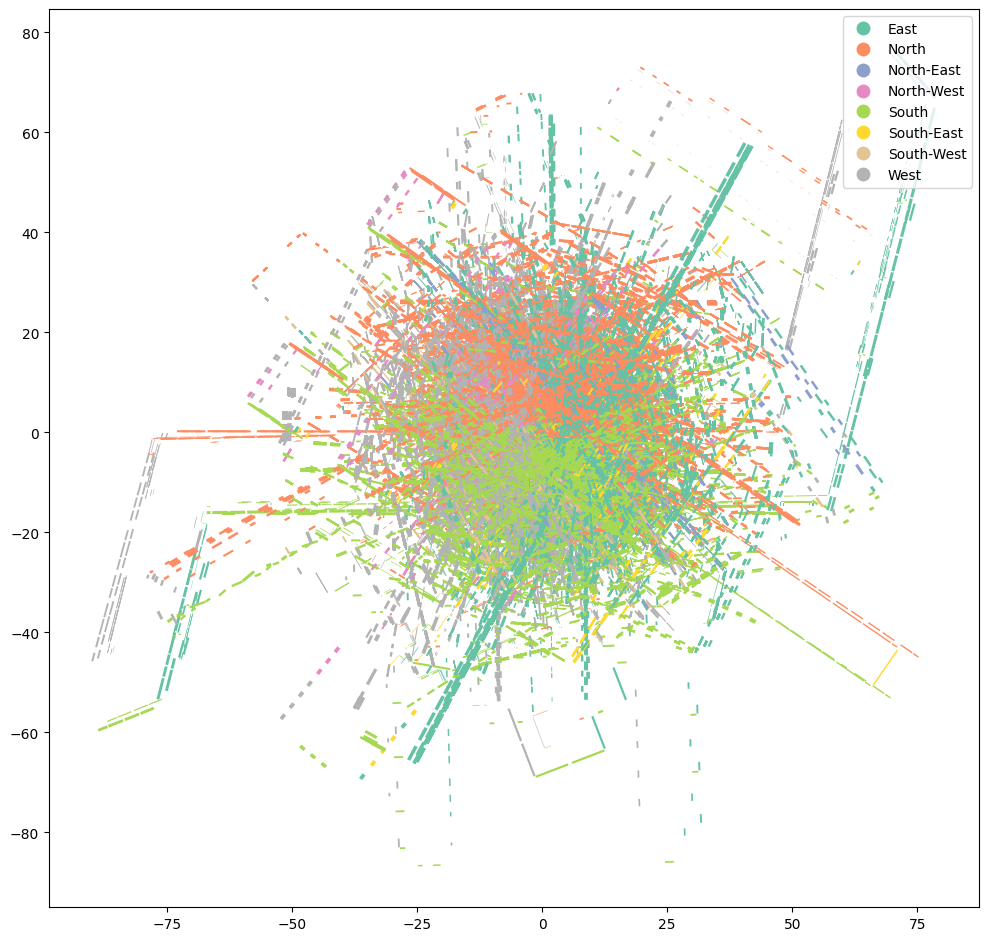

In [87]:
gpd.GeoDataFrame(OESD, geometry="geometry").plot(
    column="window_orientation", cmap="Set2", legend=True, figsize=(12, 12)
)

In [88]:
#drop the recently added columns except for window_orientation
OESD.drop(columns=['win_width', 'win_height', 'win_x', 'win_y', 'normal_angle', 'unit_x_mean', 'unit_y_mean', 'window_is_horizontal'], inplace=True)
#OESD columns
OESD.columns

Index(['apartment_id', 'site_id', 'building_id', 'plan_id', 'floor_id',
       'unit_id', 'area_id', 'entity_type', 'entity_subtype', 'geometry',
       'elevation', 'height', 'zoning', 'floor_number', 'layout_compactness',
       'layout_area', 'layout_net_area', 'layout_biggest_rectangle_length',
       'layout_biggest_rectangle_width', 'layout_number_of_doors',
       'layout_number_of_windows', 'layout_window_perimeter', 'MIF', 'AIF',
       'view_layer_urban', 'view_layer_landscape', 'view_layer_ground',
       'view_layer_sky', 'noise_night', 'acoustic_comfort',
       'window_orientation'],
      dtype='object')

In [89]:
OESD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2712485 entries, 0 to 2712484
Data columns (total 31 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   apartment_id                     object 
 1   site_id                          int64  
 2   building_id                      int64  
 3   plan_id                          int64  
 4   floor_id                         int64  
 5   unit_id                          float64
 6   area_id                          float64
 7   entity_type                      object 
 8   entity_subtype                   object 
 9   geometry                         object 
 10  elevation                        float64
 11  height                           float64
 12  zoning                           object 
 13  floor_number                     float64
 14  layout_compactness               float64
 15  layout_area                      float64
 16  layout_net_area                  float64
 17  layout_b

In [90]:
#showing all columns of OESD
pd.set_option('display.max_columns', None)
OESD

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,entity_type,entity_subtype,geometry,elevation,height,zoning,floor_number,layout_compactness,layout_area,layout_net_area,layout_biggest_rectangle_length,layout_biggest_rectangle_width,layout_number_of_doors,layout_number_of_windows,layout_window_perimeter,MIF,AIF,view_layer_urban,view_layer_landscape,view_layer_ground,view_layer_sky,noise_night,acoustic_comfort,window_orientation
0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.733784407826521 4.079807440832154...,0.0,2.6,zone03,0.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,0.483775,0.428257,1.011339,0.000000,0.010558,0.000030,17.607352,pass,<NA>
1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.733784407826521 4.079807440832154...,0.0,2.6,zone03,1.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,0.847569,0.752980,1.018274,0.000000,0.004298,0.001065,17.688069,pass,<NA>
2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,area,BATHROOM,POLYGON ((-2.733784407826521 4.079807440832154...,0.0,2.6,zone03,2.0,0.701784,3.515454,3.515454,2.357677,1.429785,1.0,1.0,0.572940,1.201388,1.067213,1.017930,0.000000,0.000963,0.004710,17.556834,pass,<NA>
3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,area,LIVING_ROOM,"POLYGON ((5.827898870188732 7.816876723402972,...",0.0,2.6,zone02,0.0,0.777285,14.088640,14.088640,4.156488,3.389554,1.0,1.0,1.859685,2.851179,2.672495,0.997827,0.004209,0.023664,0.010146,28.961584,pass,<NA>
4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,area,LIVING_ROOM,"POLYGON ((5.827898870188732 7.816876723402972,...",0.0,2.6,zone02,1.0,0.777285,14.088640,14.088640,4.156488,3.389554,1.0,1.0,1.859685,2.935869,2.952990,0.999562,0.005764,0.015051,0.012750,29.107276,pass,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712480,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,DOOR,POLYGON ((7.023406684708185 0.0777830622374562...,14.5,2.0,DOOR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
2712481,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((-3.899607375991593 -6.58509696902442...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,South
2712482,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((-0.1737787481773516 -6.5912319562452...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,South
2712483,b0027ca76f79c5363ef036f4332fe78c,855,1810,5103,8035,28198.0,NaN,opening,WINDOW,POLYGON ((3.1673230409108726 -6.59123195624521...,15.0,1.9,WINDOW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,South


In [91]:
#saving the oriented ESD dataframe, OESD as csv
OESD.to_csv('/content/gdrive/MyDrive/O-ESD/OESD.csv')

In [92]:
#detect unit ids in OESD with North-East and North and East and South window orientations
OESD.loc[OESD['window_orientation'].isin(['North-East' and 'North' and 'East' and 'South' and 'West' and 'North-West' and 'South-East' and 'South-West'])].unit_id.unique()

array([138387., 138397., 138409., ...,  73704.,  30185.,  30072.])

<Axes: >

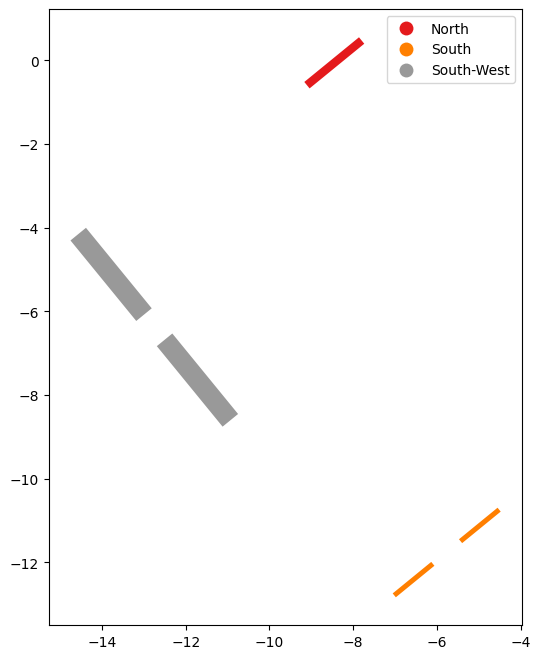

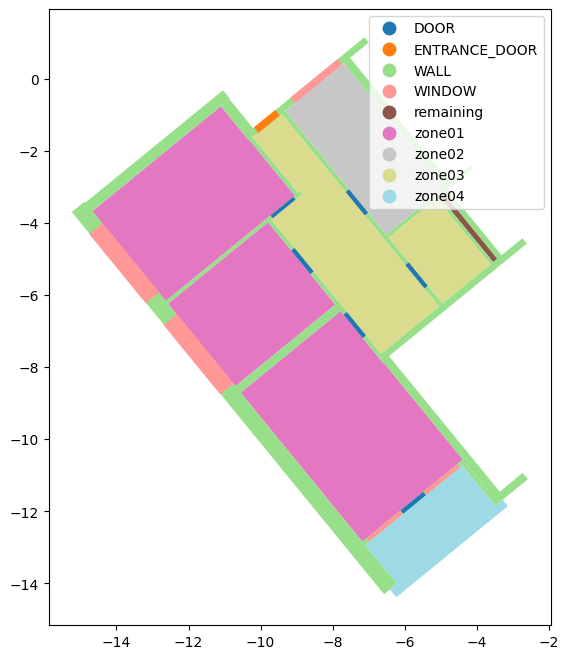

In [96]:
#finding data about specific ids
unit_30072 = OESD.loc[OESD['unit_id'] == 30072]
#geopands
gs = gpd.GeoSeries(unit_30072['geometry'])
gdf_test_floor = gpd.GeoDataFrame(unit_30072, geometry=gs, crs=None)
#plot
gdf_test_floor.plot(column='window_orientation', cmap="Set1", legend=True, figsize=(8,8))
#overlay this plot with the zonings
gdf_test_floor.plot(column='zoning', cmap="tab20", legend=True, figsize=(8,8))

<Axes: >

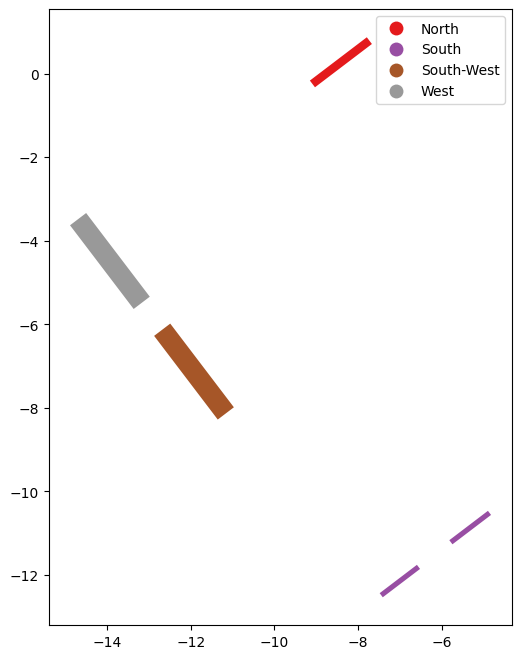

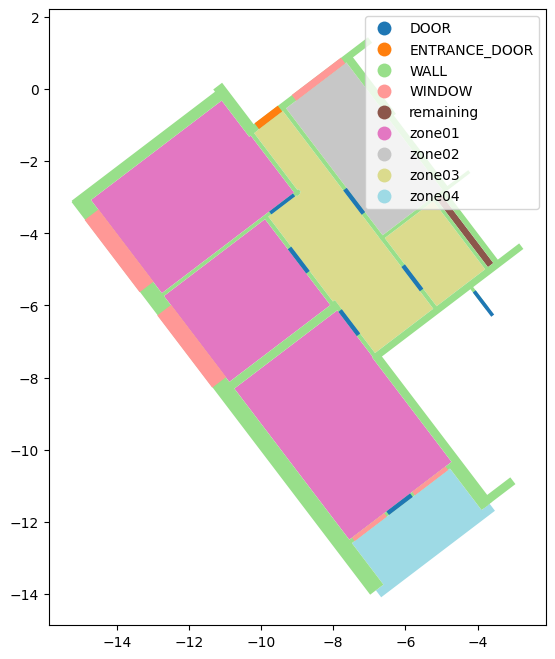

In [97]:
#finding data about specific ids
unit_73704 = OESD.loc[OESD['unit_id'] == 73704]
#geopands
gs = gpd.GeoSeries(unit_73704['geometry'])
gdf_test_floor = gpd.GeoDataFrame(unit_73704, geometry=gs, crs=None)
#plot
gdf_test_floor.plot(column='window_orientation', cmap="Set1", legend=True, figsize=(8,8))
#overlay this plot with the zonings
gdf_test_floor.plot(column='zoning', cmap="tab20", legend=True, figsize=(8,8))

In [98]:
#locate the unique unit_ids with the number of windows more than 6
OESD.loc[OESD['layout_number_of_windows'] > 5].unit_id.unique()

array([ 94561.,  94578.,  94621.,  94627., 136409., 136420., 136430.,
       136436., 136443., 103744., 103746.,  10985.,  10965.,  10990.,
        10964.,  10938.,  10988.,  11001.,  15757., 139318., 157525.,
        64558.,  64575., 145669.,  64670., 152874.,  10232., 145715.,
        64668., 112079.,  14858.,  14855.,  14856.,  14857.,  14888.,
        14889.,  14892.,  14891., 146072., 146073., 146074., 146075.,
       146076., 146077., 146078., 146080., 146079.,  13711.,  13535.,
        13649.,  13645.,  13705.,  13706.,  13644.,  13630.,  13637.,
        13650.,  13524.,  13631.,  13639.,  13520.,  13533.,  13714.,
        71509.,  71523.,  23867., 146252.,  60214.,  60316.,  60140.,
        60222.,  60122.,  60212.,  60133.,  60048.,  60065.,  60058.,
        60052.,  60060.,  60142.,  60224.,  60209.,  60144.,  59810.,
        24303.,  24304., 159325.,  15006.,  61566.,  61567.,  24551.,
        24525.,  24575.,  49370.,  65157.,  65137.,  27011.,  26491.,
        26492.,  263

In [100]:
unit_ids = [94561.,  94578.,  94621.,  94627., 136409., 136420., 136430.,
       136436., 136443., 103744., 103746.,  10985.,  10965.,  10990.,
        10964.,  10938.,  10988.,  11001.,  15757., 139318., 157525.,
        64558.,  64575., 145669.,  64670., 152874.,  10232., 145715.,
        64668., 112079.,  14858.,  14855.,  14856.,  14857.,  14888.,
        14889.,  14892.,  14891., 146072., 146073., 146074., 146075.,
       146076., 146077., 146078., 146080., 146079.,  13711.,  13535.,
        13649.,  13645.,  13705.,  13706.,  13644.,  13630.,  13637.,
        13650.,  13524.,  13631.,  13639.,  13520.,  13533.,  13714.,
        71509.,  71523.,  23867., 146252.,  60214.,  60316.,  60140.,
        60222.,  60122.,  60212.,  60133.,  60048.,  60065.,  60058.,
        60052.,  60060.,  60142.,  60224.,  60209.,  60144.,  59810.,
        24303.,  24304., 159325.,  15006.,  61566.,  61567.,  24551.,
        24525.,  24575.,  49370.,  65157.,  65137.,  27011.,  26491.,
        26492.,  26360.,  26362.,  26316.,  26363.,  26493.,  26497.,
        27010.,  27012.,  26498.,  26364.,  26315.,  27009.,  26314.,
        26499.,  26312.,  26313.,  26361.,  26317.,  26365.,   8883.,
         8897.,   9278.,   9271.,   8911.,   9274.,   8896.,   9280.,
         8913.,   9282.,   8880.,   8915.,  48377.,  48752.,  48754.,
        49316.,  49317.,  48755.,  48756.,  48376.,   8511.,  36652.,
         8505.,  11142.,  11210.,  41522.,  60607.,  60615.,  60594.,
        42348.,  42347.,  42350., 161584.,  49888.,  49876.,  49881.,
        49880.,  49878.,  49914.,  48588.,  48521.,  48522.,  49682.,
        49887.,  48631.,  48622.,  48585.,  48621., 148399., 148400.,
       148407., 148412., 148414., 148457.,  14777.,  14776.,  14790.,
        14787.,  14785.,  14780.,  14788.,   5386.,  61022.,  61023.,
       152773.,   6771.,   6778.,   6720.,   6735., 159361.,  47073.,
        15324.,  15313.,  15334.,  99609.,  43026.,  39731.,  39730.,
        13268.,  14948.,  14929.,  14968.,   8191.,   8246.,  50466.,
        70082.,  10736.,  10735., 160642., 160332., 160542.,  17389.,
        29198.,  29193.,  29194.,  29195.,  29201.,  29202.,  29203.,
        29204.,  29199.,  29196.,  29197.,  29200.,  93481.,  97741.,
        22837., 148268., 148269.,  36245.,  15804.,  15849.,  15816.,
        15831.,  52198.,  12017.,  11998.,  93160., 159335.,  11380.,
       101252., 101250.,   9973., 103467., 103468., 103469., 103470.,
       103474., 103476., 103480., 103488., 103492., 103501., 103506.,
       103514., 103553., 103554., 103555., 103556., 103557., 103558.,
       130064., 150728., 150746.,  96221.,  38572.,  38570.,  38571.,
        38569., 149038.,  15839.,  15840.,  67710.,  67711.,  67712.,
        67713.,  67709., 100141., 101493.,  66631.,  71086.,  12346.,
        51421.,  70874.,  70876.,  70877.,  36219.,  36220.,  36221.,
        43569.,  43860.,  16850., 146242.,  16003.,  16004., 141357.,
       141543.,  14226.,  14396]  # your list of unit_ids

for uid in unit_ids:
    unit_data = OESD.loc[OESD['unit_id'] == uid]
    gs = gpd.GeoSeries(unit_data['geometry'])
    gdf = gpd.GeoDataFrame(unit_data, geometry=gs, crs=None)

    # Plot window_orientation
    gdf.plot(column='window_orientation', cmap="Set1", legend=True, figsize=(8,8))

    # Plot zoning
    gdf.plot(column='zoning', cmap="tab20", legend=True, figsize=(8,8))

Output hidden; open in https://colab.research.google.com to view.